In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt


In [2]:
# === CONFIG ===
CSV_PATH = "HW_Datos_Jal.csv"   # ajusta ruta si hace falta
MIN_DATE = "2010-01-31"         # mismo corte que usas

# Carga
data = pd.read_csv(CSV_PATH)

# Renombre y selección (igual que tu notebook)
data = data.drop(columns=["HWES1"], errors="ignore")

selected_data = data[["sector_economico_1","sector_economico_2","ta","Año"]].copy()
selected_data["Año"] = pd.to_datetime(selected_data["Año"])
selected_data = selected_data[selected_data["Año"] > pd.to_datetime(MIN_DATE)]

#selected_data.head()

In [3]:
def get_sector_data_covars(data: pd.DataFrame) -> pd.DataFrame:
    """
    Replica la lógica de tu notebook:
    - sector_data: empleo total por (Año, sector_economico_1)
    - grouped_data: empleo por (Año, sector_economico_1, sector_economico_2)
    - ret_data: agrega columnas covar_s{sector}_g{group}

    Nota: mantiene el *10 para intentar cuadrar longitudes como tu código original.
    """
    sector_data = (
        data.groupby(["Año", "sector_economico_1"])["ta"]
        .sum()
        .reset_index()
    )

    grouped_data = (
        data.groupby(["Año", "sector_economico_1", "sector_economico_2"])["ta"]
        .sum()
        .reset_index()
    )

    ret_data = sector_data.copy()
    sectors = sorted(grouped_data["sector_economico_1"].unique())

    for sector in sectors:
        gdf_s = grouped_data[grouped_data["sector_economico_1"] == sector]
        groups = sorted(gdf_s["sector_economico_2"].unique())

        for group in groups:
            employments_per_group = gdf_s[gdf_s["sector_economico_2"] == group]["ta"]
            covar_name = f"covar_s{sector}_g{group}"

            # Mantener tu estructura (*10) para cuadrar dimensiones
            covar_col = list(employments_per_group.values) * 10

            if len(covar_col) == len(ret_data):
                ret_data[covar_name] = covar_col
            else:
                # Si no cuadra, se omite (igual intención que tu notebook)
                pass

    return ret_data

sector_df = get_sector_data_covars(selected_data)
sector_df.head(3)

,Año,sector_economico_1,ta,covar_s0.0_g1.0,covar_s0.0_g2.0,covar_s0.0_g3.0,covar_s0.0_g4.0,covar_s0.0_g5.0,covar_s1.0_g11.0,covar_s1.0_g12.0,...,covar_s8.0_g85.0,covar_s8.0_g86.0,covar_s8.0_g87.0,covar_s8.0_g88.0,covar_s8.0_g89.0,covar_s9.0_g91.0,covar_s9.0_g92.0,covar_s9.0_g93.0,covar_s9.0_g94.0,covar_s9.0_g99.0
0,2010-02-28,0.0,57171,40878,15525,448,314,6,1383,5,...,3926,21884,33623,11836,35783,39956,17662,5346,162505,117
1,2010-02-28,1.0,2153,41721,15533,517,301,6,1377,5,...,3820,21575,33300,11926,35759,39307,18138,5490,162892,118
2,2010-02-28,2.0,151243,38311,15637,505,317,6,1348,5,...,3821,21275,33291,11865,35589,38890,18514,5632,163256,120


In [4]:
AGRI_SECTOR_CODE = 0  # Agricultura típicamente es 0

agri_df = sector_df[sector_df["sector_economico_1"] == AGRI_SECTOR_CODE].copy()
agri_df = agri_df.sort_values("Año")

print("Observaciones Agricultura disponibles:", len(agri_df))
agri_df.head(3)

Observaciones Agricultura disponibles: 162


,Año,sector_economico_1,ta,covar_s0.0_g1.0,covar_s0.0_g2.0,covar_s0.0_g3.0,covar_s0.0_g4.0,covar_s0.0_g5.0,covar_s1.0_g11.0,covar_s1.0_g12.0,...,covar_s8.0_g85.0,covar_s8.0_g86.0,covar_s8.0_g87.0,covar_s8.0_g88.0,covar_s8.0_g89.0,covar_s9.0_g91.0,covar_s9.0_g92.0,covar_s9.0_g93.0,covar_s9.0_g94.0,covar_s9.0_g99.0
0,2010-02-28,0.0,57171,40878,15525,448,314,6,1383,5,...,3926,21884,33623,11836,35783,39956,17662,5346,162505,117
10,2010-03-31,0.0,58078,43409,16401,392,338,6,1444,5,...,4093,22937,33964,12188,36363,39568,17945,5797,167033,126
20,2010-04-30,0.0,54776,43803,17197,374,170,5,1365,4,...,4250,24004,35386,13643,37838,41266,19246,6026,172875,122


In [5]:
N = 80

# Opción A: primeras 80 (recomendado si quieres mantener orden temporal desde el arranque)
agri_80 = agri_df.iloc[:N].copy()

# Opción B: últimas 80 (si prefieres lo más reciente)
# agri_80 = agri_df.iloc[-N:].copy()

print("Observaciones usadas:", len(agri_80))
#agri_80[["Año","sector_economico_1","ta"]]
agri_80


Observaciones usadas: 80


,Año,sector_economico_1,ta,covar_s0.0_g1.0,covar_s0.0_g2.0,covar_s0.0_g3.0,covar_s0.0_g4.0,covar_s0.0_g5.0,covar_s1.0_g11.0,covar_s1.0_g12.0,...,covar_s8.0_g85.0,covar_s8.0_g86.0,covar_s8.0_g87.0,covar_s8.0_g88.0,covar_s8.0_g89.0,covar_s9.0_g91.0,covar_s9.0_g92.0,covar_s9.0_g93.0,covar_s9.0_g94.0,covar_s9.0_g99.0
0,2010-02-28,0.0,57171,40878,15525,448,314,6,1383,5,...,3926,21884,33623,11836,35783,39956,17662,5346,162505,117
10,2010-03-31,0.0,58078,43409,16401,392,338,6,1444,5,...,4093,22937,33964,12188,36363,39568,17945,5797,167033,126
20,2010-04-30,0.0,54776,43803,17197,374,170,5,1365,4,...,4250,24004,35386,13643,37838,41266,19246,6026,172875,122
30,2010-05-31,0.0,53586,42259,16762,454,198,4,1337,4,...,4448,23723,36440,12893,41294,42228,19572,6303,171025,124
40,2010-06-30,0.0,54004,50158,15245,493,186,5,1450,5,...,3718,23677,38271,15135,42224,39832,20336,6945,176790,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,2016-05-31,0.0,78763,77336,20137,451,233,31,1442,19,...,6195,28393,51127,18058,48262,51128,24848,6313,185598,126
760,2016-06-30,0.0,78155,70330,21032,442,236,37,1343,32,...,6252,31207,52986,20154,46102,46496,25269,5970,187267,124
770,2016-07-31,0.0,78941,89623,22244,452,356,40,1404,12,...,6111,25726,44742,16515,45651,48638,26909,6097,192155,149
780,2016-08-31,0.0,81634,89875,22142,445,416,44,1358,10,...,5801,26119,44855,14669,47371,45150,29054,5792,193115,145


In [6]:
# Las covariables empiezan después de las columnas: Año, sector_economico_1, ta
covars_agri = agri_80.iloc[:, 3:].copy()

# Limpieza numérica
covars_agri = covars_agri.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Shape covariables:", covars_agri.shape)
print("Primeras columnas:", covars_agri.columns[:5].tolist())


Shape covariables: (80, 61)
Primeras columnas: ['covar_s0.0_g1.0', 'covar_s0.0_g2.0', 'covar_s0.0_g3.0', 'covar_s0.0_g4.0', 'covar_s0.0_g5.0']


In [7]:
# En tu notebook original, asumías que la primera covariable corresponde al primer grupo listado.
# Aquí lo hacemos explícito: Y = primera columna, X = resto.
y_name = covars_agri.columns[0]
y = covars_agri[y_name]

X = covars_agri.drop(columns=[y_name])
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print("Variable dependiente (Agricultura proxy):", y_name)
#model.summary()

Variable dependiente (Agricultura proxy): covar_s0.0_g1.0


In [8]:
alpha = 0.05

print("R2:", model.rsquared)
print("Adj R2:", model.rsquared_adj)
print("F-test p-value:", model.f_pvalue)

results_df = pd.DataFrame({
    "Beta": model.params,
    "p_value": model.pvalues,
})
results_df["Significant_5%"] = results_df["p_value"] < alpha
results_df["abs_Beta"] = results_df["Beta"].abs()

# Top 20 por magnitud
display(results_df.sort_values("abs_Beta", ascending=False).head())

R2: 0.9960764648255084
Adj R2: 0.9836863537481664
F-test p-value: 4.045332830098208e-15


,Beta,p_value,Significant_5%,abs_Beta
const,62873.743443,0.678394,False,62873.743443
covar_s1.0_g12.0,-480.808210,0.105834,False,480.808210
covar_s9.0_g99.0,236.115510,0.231574,False,236.115510
covar_s0.0_g5.0,-114.136109,0.716979,False,114.136109
covar_s5.0_g51.0,-19.380868,0.169582,False,19.380868


In [9]:
alpha = 0.05

top_sig = results_df[(results_df.index != "const") & (results_df["Significant_5%"])].copy()
top_sig = top_sig.sort_values("abs_Beta", ascending=False).head(20)

display(top_sig[["Beta","p_value","Significant_5%"]])

,Beta,p_value,Significant_5%
covar_s0.0_g4.0,-13.017543,0.010236,True
covar_s3.0_g36.0,3.248912,0.043076,True


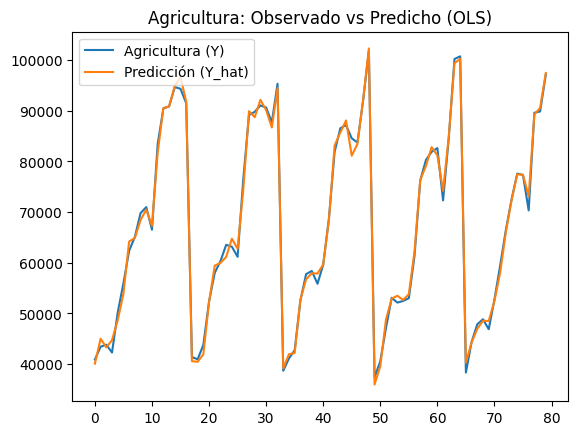

In [10]:
y_hat = model.predict(X)

plt.figure()
plt.plot(y.values, label="Agricultura (Y)")
plt.plot(y_hat.values, label="Predicción (Y_hat)")
plt.title("Agricultura: Observado vs Predicho (OLS)")
plt.legend()
plt.show()

# EVALUACION

In [11]:
# Tomar el resto como conjunto de prueba
agri_test = agri_df.iloc[80:].copy()

print("Observaciones prueba:", len(agri_test))

Observaciones prueba: 82


In [12]:
# Construir matriz covariables del test
covars_test = agri_test.iloc[:, 3:].copy()
covars_test = covars_test.replace([np.inf, -np.inf], np.nan).fillna(0)

# Definir X_test (mismas columnas que usaste en training)
X_test = covars_test.drop(columns=[y_name])  # quitar la variable dependiente
X_test = sm.add_constant(X_test)

# Asegurar que el orden de columnas sea igual al del modelo
X_test = X_test[model.params.index]

In [13]:
# Predicción out-of-sample
y_test_real = covars_test[y_name]
y_test_pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
mae = mean_absolute_error(y_test_real, y_test_pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 1195.3669164758987
MAE: 947.9359847755651


In [15]:
ss_res = np.sum((y_test_real - y_test_pred)**2)
ss_tot = np.sum((y_test_real - y_test_real.mean())**2)

r2_out = 1 - ss_res/ss_tot

print("R2 fuera de muestra:", r2_out)

R2 fuera de muestra: 0.9961896478164354


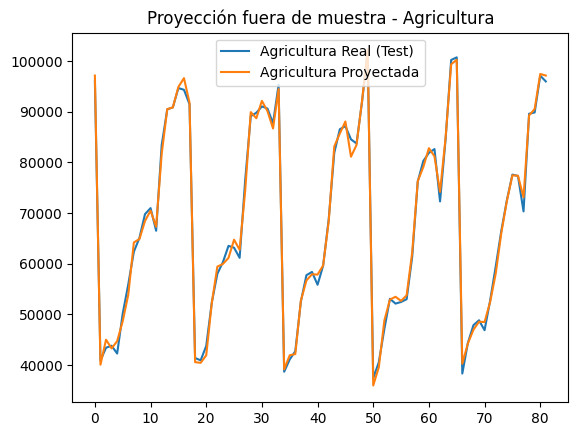

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test_real.values, label="Agricultura Real (Test)")
plt.plot(y_test_pred.values, label="Agricultura Proyectada")
plt.title("Proyección fuera de muestra - Agricultura")
plt.legend()
plt.show()

# PROYECCIÓN DEL MODELO

In [17]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error

N_TRAIN = 80

# Asegurar orden temporal
agri_df = agri_df.sort_values("Año").reset_index(drop=True)

agri_train = agri_df.iloc[:N_TRAIN].copy()
agri_test  = agri_df.iloc[N_TRAIN:].copy()

print("Train:", agri_train.shape, "| Test:", agri_test.shape)

Train: (80, 64) | Test: (82, 64)


In [18]:
# Covariables (todo lo que está después de Año, sector_economico_1, ta)
covars_train = agri_train.iloc[:, 3:].copy()
covars_train = covars_train.replace([np.inf, -np.inf], np.nan).fillna(0)

# Definir Y como la misma que estabas usando (primera covariable)
y_name = covars_train.columns[0]
y_train = covars_train[y_name]

# X = todas las demás covariables + constante
X_train = covars_train.drop(columns=[y_name])
X_train = sm.add_constant(X_train)

In [19]:
model = sm.OLS(y_train, X_train).fit()

print("Variable objetivo (Y):", y_name)
print("R2 train:", model.rsquared)
print("Adj R2 train:", model.rsquared_adj)
print("F-test p-value train:", model.f_pvalue)

Variable objetivo (Y): covar_s0.0_g1.0
R2 train: 0.9960764648255084
Adj R2 train: 0.9836863537481664
F-test p-value train: 4.045332830098208e-15


In [20]:
covars_test = agri_test.iloc[:, 3:].copy()
covars_test = covars_test.replace([np.inf, -np.inf], np.nan).fillna(0)

y_test_real = covars_test[y_name]

X_test = covars_test.drop(columns=[y_name])
X_test = sm.add_constant(X_test)

# MUY IMPORTANTE: alinear columnas y orden EXACTO a lo que el modelo espera
# (si alguna columna faltara en test, se crea en 0; si sobran, se eliminan)
X_test = X_test.reindex(columns=model.params.index, fill_value=0)

# Proyección (sin “ver” y_test_real para entrenar; solo se usa para comparar al final)
y_test_pred = model.predict(X_test)

In [21]:
rmse = np.sqrt(mean_squared_error(y_test_real, y_test_pred))
mae  = mean_absolute_error(y_test_real, y_test_pred)

# R2 out-of-sample (definición estándar)
ss_res = np.sum((y_test_real - y_test_pred)**2)
ss_tot = np.sum((y_test_real - y_test_real.mean())**2)
r2_out = 1 - ss_res / ss_tot

print("=== OUT-OF-SAMPLE (82 periodos) ===")
print("RMSE:", rmse)
print("MAE :", mae)
print("R2  :", r2_out)


=== OUT-OF-SAMPLE (82 periodos) ===
RMSE: 1195.3669164758987
MAE : 947.9359847755651
R2  : 0.9961896478164354


In [22]:
results_oos = pd.DataFrame({
    "Año": agri_test["Año"].values,
    "Y_real": y_test_real.values,
    "Y_pred": y_test_pred.values
})

results_oos["error"] = results_oos["Y_real"] - results_oos["Y_pred"]
results_oos["abs_error"] = results_oos["error"].abs()

display(results_oos.head(10))
display(results_oos.tail(10))


,Año,Y_real,Y_pred,error,abs_error
0,2016-10-31,96008,97167.106730,-1159.106730,1159.106730
1,2016-11-30,40878,40059.745678,818.254322,818.254322
2,2016-12-31,43409,44993.052485,-1584.052485,1584.052485
3,2017-01-31,43803,43285.215091,517.784909,517.784909
4,2017-02-28,42259,44701.023245,-2442.023245,2442.023245
5,2017-03-31,50158,48665.391902,1492.608098,1492.608098
6,2017-04-30,55947,53914.214765,2032.785235,2032.785235
7,2017-05-31,62378,64195.932629,-1817.932629,1817.932629
8,2017-06-30,65091,64879.143429,211.856571,211.856571
9,2017-07-31,69794,68435.315272,1358.684728,1358.684728


,Año,Y_real,Y_pred,error,abs_error
72,2022-10-31,59420,58046.532343,1373.467657,1373.467657
73,2022-11-30,66457,66023.773891,433.226109,433.226109
74,2022-12-31,72504,72338.116897,165.883103,165.883103
75,2023-01-31,77603,77459.986530,143.013470,143.013470
76,2023-02-28,77336,77381.260211,-45.260211,45.260211
77,2023-03-31,70330,73122.737801,-2792.737801,2792.737801
78,2023-04-30,89623,89295.169379,327.830621,327.830621
79,2023-05-31,89875,90564.925900,-689.925900,689.925900
80,2023-06-30,97140,97477.513271,-337.513271,337.513271
81,2023-07-31,96008,97167.106730,-1159.106730,1159.106730


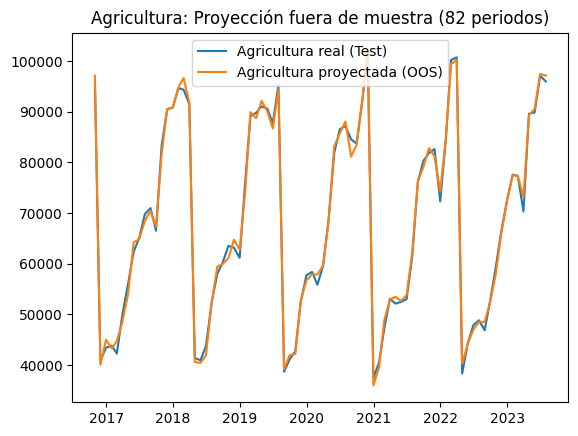

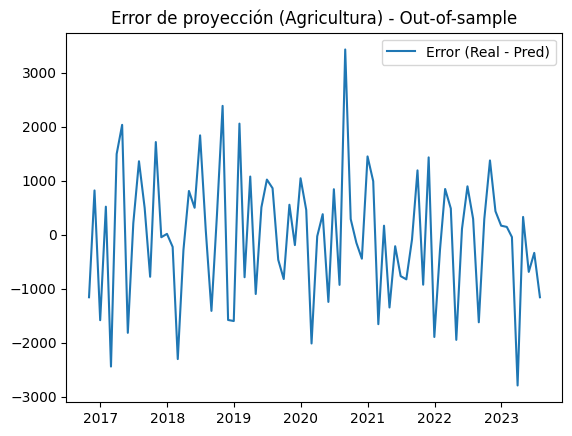

In [23]:
plt.figure()
plt.plot(results_oos["Año"], results_oos["Y_real"], label="Agricultura real (Test)")
plt.plot(results_oos["Año"], results_oos["Y_pred"], label="Agricultura proyectada (OOS)")
plt.title("Agricultura: Proyección fuera de muestra (82 periodos)")
plt.legend()
plt.show()

plt.figure()
plt.plot(results_oos["Año"], results_oos["error"], label="Error (Real - Pred)")
plt.title("Error de proyección (Agricultura) - Out-of-sample")
plt.legend()
plt.show()


In [24]:
alpha = 0.05

drivers = pd.DataFrame({
    "beta": model.params,
    "p_value": model.pvalues
})
drivers["abs_beta"] = drivers["beta"].abs()
drivers["significant_5%"] = drivers["p_value"] < alpha

# Excluir la constante para ranking
drivers_no_const = drivers.drop(index=["const"], errors="ignore").sort_values("abs_beta", ascending=False)

display(drivers_no_const.head(20))


,beta,p_value,abs_beta,significant_5%
covar_s1.0_g12.0,-480.808210,0.105834,480.808210,False
covar_s9.0_g99.0,236.115510,0.231574,236.115510,False
covar_s0.0_g5.0,-114.136109,0.716979,114.136109,False
covar_s5.0_g51.0,-19.380868,0.169582,19.380868,False
covar_s0.0_g3.0,-18.720407,0.147709,18.720407,False
covar_s7.0_g72.0,-15.331673,0.200923,15.331673,False
covar_s0.0_g4.0,-13.017543,0.010236,13.017543,True
covar_s2.0_g26.0,8.988148,0.192606,8.988148,False
covar_s2.0_g23.0,-8.880174,0.164317,8.880174,False
covar_s2.0_g22.0,-7.202593,0.527903,7.202593,False
